# Ablation study for sliding windows

This tutorials shows how to set up an multiple slide molecular cartography dataset used from [Legnini et al., 2023](https://doi.org/10.1038/s41592-023-01986-w). To follow along with this and the following tutorials, please execute the following steps first:

- Set up InterScale environment (see instructions in ReadMe)
- Download the sample data from the original publication from [Zenodo](https://doi.org/10.5281/zenodo.6143560) under the accession no. 6143561

In [1]:
import scanpy as sc
import squidpy as sq
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.sparse import issparse
import seaborn as sns
from scipy.sparse import csr_array, csr_matrix, issparse
import interscale

from pathlib import Path

import warnings
warnings.filterwarnings('ignore')

In [2]:
import os

# LRZ home
if os.path.exists("/dss/dsshome1/05/di93tig"):
    print('LRZ cluster')
    CLUSTER = 'LRZ'
    BASE_DIR_REPO = "/dss/dsshome1/05/di93tig/1_projects" 
    BASE_DIR_PROJECT = "/dss/dssfs03/tumdss/pn36po/pn36po-dss-0002/di93tig/Projects/A3_InterScale"
elif os.path.exists("/home/icb/francesca.drummer/"):
    print('HPC cluster')
    CLUSTER = 'HPC'
    BASE_DIR_REPO = "/home/icb/francesca.drummer/1-Projects/A3_InterScale/"
    BASE_DIR_PROJECT = "/lustre/groups/ml01/projects/2024_spatial_long_range_GT_francesca.drummer/"
else:
    print('unkown')
    CLUSTER = 'unknown'
DATA = "legnini23"

HPC cluster


In [3]:
import yaml
with open(os.path.join(BASE_DIR_REPO, "InterScale_reproducibility/figures/config.yml"), "r") as f:
    config = yaml.safe_load(f)

PALETTE = config["palettes"]["continuous"]
#CELL_TYPE_COLORS = config["palettes"][DATA]

slides = config["slide_examples"]["legnini23"]

<mark>TODO: Change data path</mark>

In [4]:
LRZ_LEGNINI23 = f'{BASE_DIR_PROJECT}/data/{DATA}.h5ad'  

## Load data

In [5]:
adata = sc.read_h5ad(LRZ_LEGNINI23)
adata

AnnData object with n_obs × n_vars = 43762 × 88
    obs: 'Cell', 'Area', 'x', 'y', 'sample', 'condition', 'organoid', 'obs_names', 'split'
    var: 'gene_ids', 'feature_types'
    obsm: 'spatial'
    layers: 'log1p_norm', 'norm_ftsqrt', 'raw', None (.X)

In [6]:
print('Zero count cells: ', (adata.X.sum(1) ==0).sum())

Zero count cells:  648


### SHH rings

In [7]:
# only needed when re-running on an adata that already carries the zones
adata.obs.drop(columns=["SHH_zone"], errors="ignore", inplace=True)

In [8]:
from interscale.tl import clustering

# The last edge is open-ended on purpose. create_spatial_cluster_distance bins
# dist_to_SHH with pd.cut, so any cell beyond the last edge becomes NaN in
# SHH_zone. With a closed edge at 6000 that silently dropped 685 cells of
# slide1_C2-2 (dist_to_SHH 6000-8034, the only slide reaching that far), and the
# NaN propagated into sliding_window_low -> scvi's CategoricalObsField assigns
# code -1 and register_fields dies with
#   ValueError: Making .obs["sliding_window_low"] categorical failed.
# np.inf puts that tail into 'far', where it belongs, and keeps 4 rings.
ring_edges  = [0, 200, 2000, 3000, np.inf]
ring_labels = ['SHH', 'near', 'medium', 'far']

clustering.create_spatial_cluster_distance(
    adata, 'SHH', 'sample',
    distance_bins=ring_edges,
    bin_labels=ring_labels,
    threshold=95,
)

AnnData object with n_obs × n_vars = 43762 × 88
    obs: 'Cell', 'Area', 'x', 'y', 'sample', 'condition', 'organoid', 'obs_names', 'split', 'dist_to_SHH', 'SHH_zone'
    var: 'gene_ids', 'feature_types'
    obsm: 'spatial'
    layers: 'log1p_norm', 'norm_ftsqrt', 'raw', None (.X)

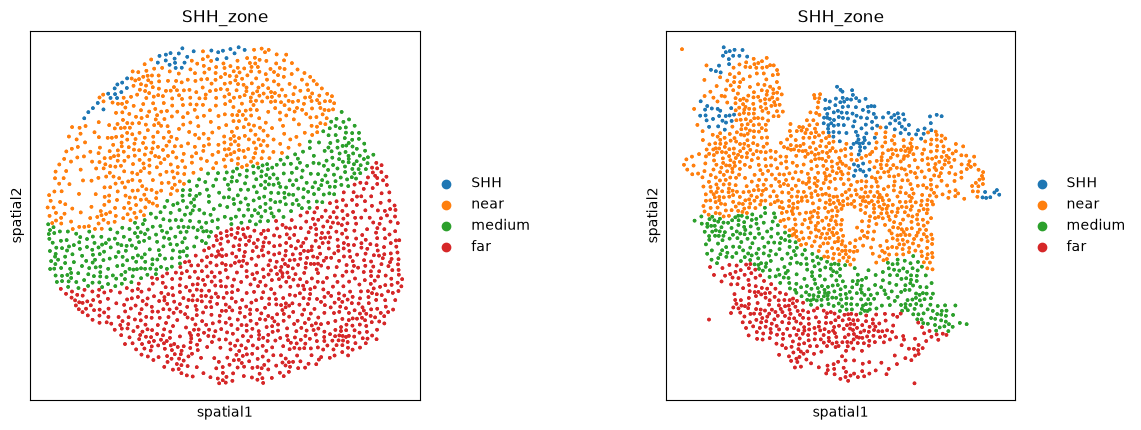

In [9]:
sq.pl.spatial_scatter(
    adata[adata.obs['sample'].isin([slides["Ctrl"], slides["SSH"]])],
    spatial_key = 'spatial',
    library_key='sample', 
    #library_id = [839, 6],
    color="SHH_zone", #cell_type_coarse",
    shape= None,
    size = 10,
)

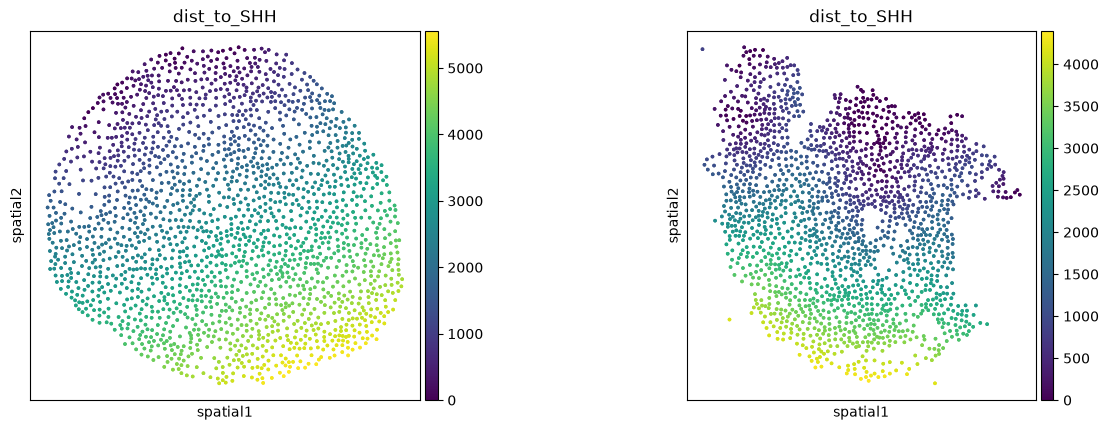

In [10]:
sq.pl.spatial_scatter(
    adata[adata.obs['sample'].isin([slides["Ctrl"], slides["SSH"]])],
    spatial_key = 'spatial',
    library_key='sample', 
    #library_id = [839, 6],
    color="dist_to_SHH", #cell_type_coarse",
    shape= None,
    size = 10,
)

Check that no NaN's exists in the data.

In [11]:
# dropna=False: a plain groupby().size() hides exactly the NaNs this checks for
print(adata.obs["SHH_zone"].value_counts(dropna=False))
assert adata.obs["SHH_zone"].isna().sum() == 0, (
    "cells outside every ring - widen ring_edges (the last edge must cover max(dist_to_SHH))"
)

SHH_zone
near          25023
medium         9043
far            8110
SHH            1586
No_Source         0
Background        0
Name: count, dtype: int64


### Prepare sliding windows and cell type annotations

The idea is that I will have sliding windows each including a different rings, hence different overlap.
- High overlap: rings 1,2; 2,3; 3,4
- Low overlap: rings 1;2;3;4 

In [12]:
adata.obs['cell_type'] = adata.obs['SHH_zone'].astype(str)

In [19]:
# ---- Low overlap: 3-ring windows, stride 1 ----
adata.obs['sliding_window_low'] = adata.obs['SHH_zone'].astype(str)


def make_sliding_windows(ring_series, ring_labels, width, stride, prefix):
    ring_to_idx = {r: i for i, r in enumerate(ring_labels)}
    idx = ring_series.map(ring_to_idx).values
    n = len(ring_labels)

    window_defs, start = [], 0
    while start < n:
        rings = list(range(start, min(start + width, n)))
        window_defs.append(rings)
        if start + width >= n:
            break
        start += stride

    out = pd.DataFrame(index=ring_series.index)
    for rings in window_defs:
        name = f"{prefix}_{'_'.join(ring_labels[r] for r in rings)}"
        out[name] = np.isin(idx, rings)
    return out

# ---- High overlap: 3-ring windows, stride 1 ----
windows_high = make_sliding_windows(
    adata.obs['SHH_zone'], ring_labels, width=3, stride=1, prefix='sliding_window_high'
)
for col in windows_high.columns:
    adata.obs[col] = windows_high[col].values

In [20]:
adata

AnnData object with n_obs × n_vars = 43762 × 88
    obs: 'Cell', 'Area', 'x', 'y', 'sample', 'condition', 'organoid', 'obs_names', 'split', 'dist_to_SHH', 'SHH_zone', 'cell_type', 'sliding_window_low', 'sliding_window_high_SHH_near_medium', 'sliding_window_high_near_medium_far'
    var: 'gene_ids', 'feature_types'
    obsm: 'spatial'
    layers: 'log1p_norm', 'norm_ftsqrt', 'raw', None (.X)

In [43]:
# ---- Scope every window to a slide ----
# A bare True/False membership mask is not a window: grouping by it pools all 17
# samples into 2 graphs (largest 42176 cells), which is neither the ablation designed
# above nor something any max_seq_len can hold. That is what produced
#   AssertionError: Local and global predictions have different lengths: 3196 vs 2631
# - tl/padding.py truncates the global branch to max_seq_len while the local branch
# keeps every node. Folding `sample` into the window id gives one graph per
# (sample, window), which is what "sliding window" was supposed to mean.

sample_ser = adata.obs['sample']


def scoped_window(mask, sample, name):
    """Window id per cell: '<sample>__<name>' inside the window, NaN outside."""
    ids = pd.Series(pd.NA, index=mask.index, dtype=object)
    ids[mask.values] = sample[mask.values].astype(str) + f"__{name}"
    return pd.Categorical(ids)


# Low overlap: every cell sits in exactly one ring, so this stays NaN-free and is
# usable as a sample_key directly. '__' separates the two halves because the sample
# names themselves contain '_'.
adata.obs['sliding_window_low'] = pd.Categorical(
    sample_ser.astype(str) + '__' + adata.obs['SHH_zone'].astype(str)
)

# High overlap: one categorical window-id column per window, NaN outside it. The NaN
# is deliberate - those cells must not form graphs - which is why these columns need
# the per-arm subsets written below rather than the shared _pp.h5ad.
for col in windows_high.columns:
    adata.obs[col] = scoped_window(
        windows_high[col], sample_ser, col.replace('sliding_window_high_', '')
    )

# Graph sizes each arm would build -> read max_seq_len for the registry off `largest`.
print(f"{'column':40s} {'n_graphs':>8s} {'largest':>8s} {'median':>7s} {'outside':>8s}")
for col in ['sliding_window_low', *windows_high.columns]:
    s = adata.obs[col].value_counts()
    s = s[s > 0]
    print(
        f"{col:40s} {len(s):8d} {s.max():8d} {int(s.median()):7d} "
        f"{adata.obs[col].isna().sum():8d}"
    )

# scvi's CategoricalObsField turns an unmapped value into code -1 and aborts
# register_fields, so the column an arm uses as sample_key must be NaN-free.
assert adata.obs['sliding_window_low'].isna().sum() == 0, (
    "sliding_window_low must be NaN-free"
)

column                                   n_graphs  largest  median  outside
sliding_window_low                             64     2812     483        0
sliding_window_high_SHH_near_medium            17     3882    1817     8110
sliding_window_high_near_medium_far            17     4239    2434     1586


In [47]:
for sliding_window_str in ['sliding_window_high_SHH_near_medium', 'sliding_window_high_near_medium_far']:
    adata.obs[sliding_window_str] = adata.obs[sliding_window_str].astype('object')
    adata.obs['sample'] = adata.obs['sample'].astype('object')
    
    # Extract suffix and create 'not_near' variant
    suffix = sliding_window_str.replace('sliding_window_high_', '')
    not_near_suffix = suffix.replace('near', 'not_near')
    
    mask = pd.isna(adata.obs[sliding_window_str])
    adata.obs.loc[mask, sliding_window_str] = (
        adata.obs.loc[mask, 'sample'] + '__' + not_near_suffix
    )

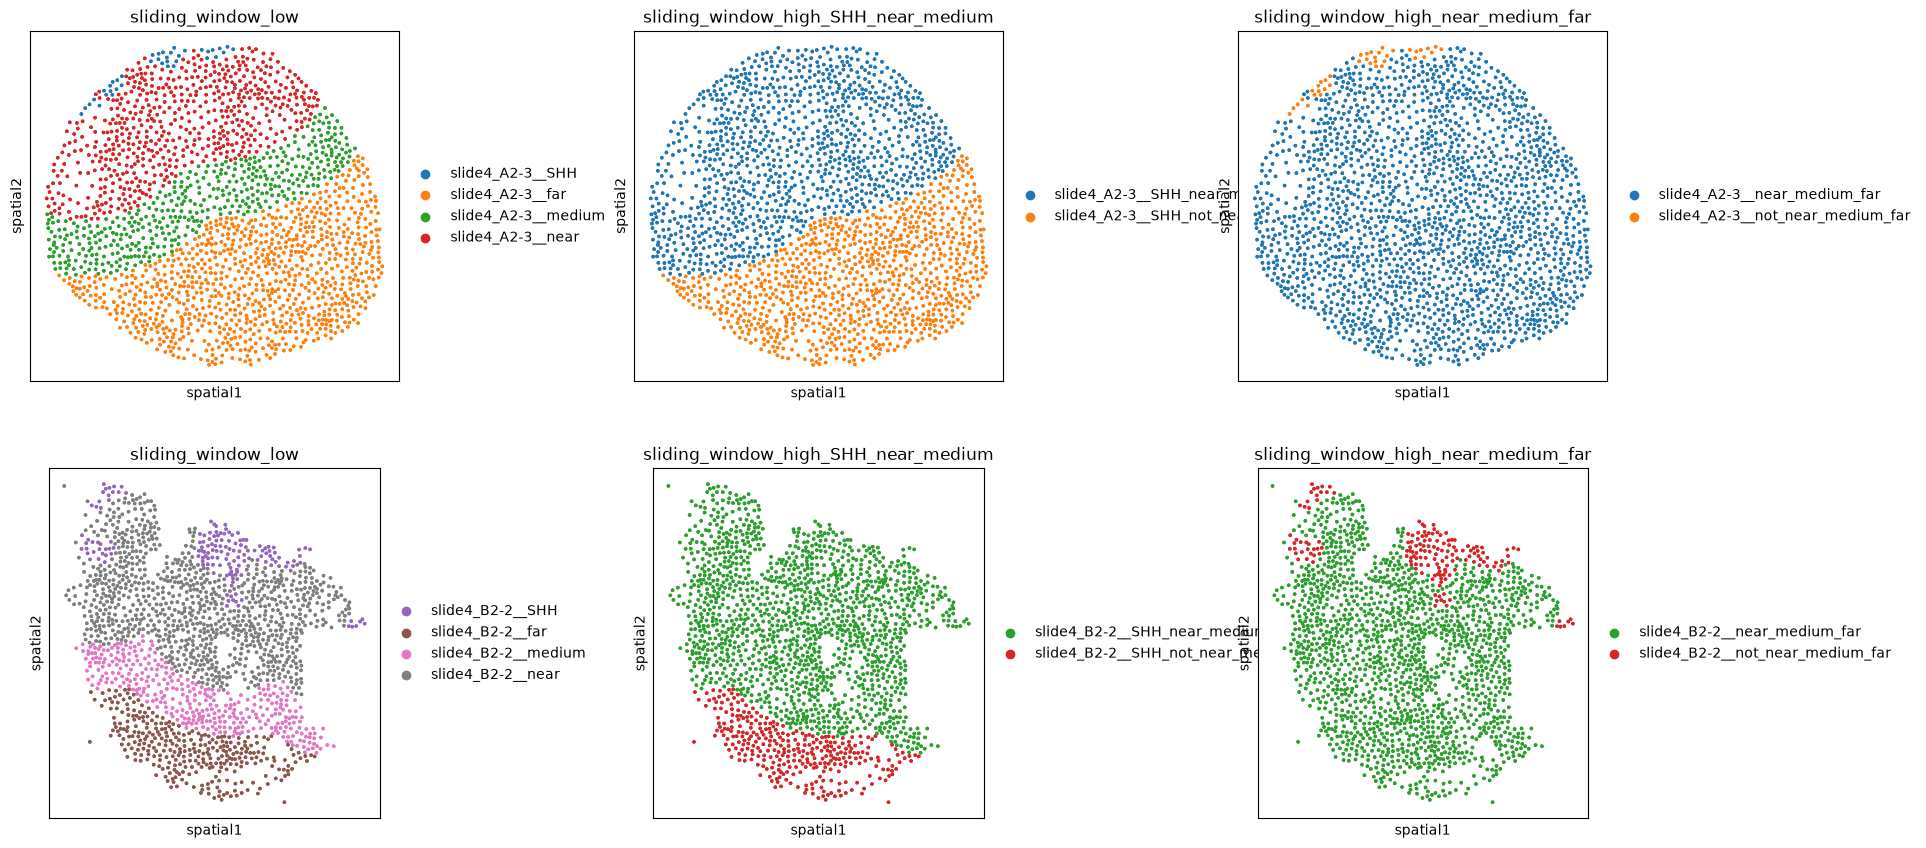

In [53]:
sq.pl.spatial_scatter(
    adata[adata.obs['sample'].isin([slides["Ctrl"], slides["SSH"]])],
    spatial_key = 'spatial',
    library_key='sample', 
    #library_id = [839, 6],
    color=['sliding_window_low', "sliding_window_high_SHH_near_medium",'sliding_window_high_near_medium_far'], #cell_type_coarse",
    shape= None,
    ncols = 3,
    size = 10,
)

In [49]:
adata.write(f'{BASE_DIR_PROJECT}/data/{DATA}_pp.h5ad')

In [18]:
adata.obs['sliding_window_low']

0           SHH
1          near
2           SHH
3          near
4          near
          ...  
43757    medium
43758       far
43759       far
43760    medium
43761       far
Name: sliding_window_low, Length: 43762, dtype: category
Categories (4, str): ['SHH' < 'near' < 'medium' < 'far']

## Load trained models

In [7]:
import os
from pathlib import Path

import wandb

from interscale.config.registry import resolve_config
from interscale.evaluation import plot_global_directionality
from interscale.evaluation.net_streams import compute_hierarchical_net_flow
from interscale.tl.utils import set_full_reproducibility

REGISTRY      = Path(BASE_DIR_REPO) / "interscale" / "config_files" / "registry.yaml"
WANDB_PROJECT = "francesca-drummer/GTLongRange_Legnini23"
ARTIFACT_DIR  = Path(BASE_DIR_PROJECT) / "wandb_artifacts"

wandb.login()

wandb: ERROR Failed to detect the name of this notebook. You can set it manually with the WANDB_NOTEBOOK_NAME environment variable to enable code saving.
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /home/icb/francesca.drummer/.netrc.
wandb: Currently logged in as: francesca-drummer to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

In [12]:
adata = sc.read_h5ad(f'{BASE_DIR_PROJECT}/data/{DATA}_pp.h5ad')

In [8]:
# W&B run id for each ablation arm (fill in as the runs finish).
#
# The old single `medium` arm carried both high-overlap window columns in one `sample_key`.
# That trained on both windowings but evaluated on only the first: prepare_geome_dataset
# (training) loops over every sample_key column and extends, while prepare_a2d_dataset
# (get_model_output) returns inside that same loop, so inference only ever sees sample_key[0].
# It is now split into medium_snm / medium_nmf, one column each.
#
# Superseded runs, all trained at max_seq_len 2000 and therefore on randomly subsampled
# windows: medium bi9dbmbj, coarse zcna6r39, medium ra7q3kib (the both-columns retrain).
RUN_IDS = {
    "full_slide": "o1b6yyqe",
    "medium_snm": "uuinehx7",
    "medium_nmf": "62hfjx69",
    "coarse":     "d537he74",
}

In [9]:
from typing import Literal

PIXEL_TO_UM = 0.138  # Resolve MC1 default; override via cfg if instrument differs

def get_average_local_and_global_size(
    adata,
    cfg,
    *,
    coord_units: Literal["pixels", "micrometer"] = "micrometer",
    pixel_size_um: float = PIXEL_TO_UM,
):
    """Average size of the local and the global window, in cells and in micrometers.

    Parameters
    ----------
    coord_units
        Units of ``adata.obsm['spatial']``. If ``"pixels"``, distances are
        converted to micrometers using ``pixel_size_um``.
    pixel_size_um
        Micrometers per pixel. Ignored when ``coord_units='micrometer'``.
    """
    scale = pixel_size_um if coord_units == "pixels" else 1.0

    ## Local: avg direct-neighbor count * n_layers
    if "spatial_connectivities" not in adata.obsp:
        kwargs = dict(cfg.dataset.spatial_neigbors_kwargs)
        # library_key is only filled in by prepare_geome_dataset, so pick the first sample key here
        kwargs["library_key"] = kwargs.get("library_key") or cfg.dataset.sample_key[0]
        adata.obs[kwargs["library_key"]] = adata.obs[kwargs["library_key"]].astype("category")
        sq.gr.spatial_neighbors(adata, **kwargs)
    n_layers = cfg.model.local_component.parameters.num_layers
    conn = adata.obsp["spatial_connectivities"].tocsr()
    local_cells = conn.getnnz(axis=1).mean() * n_layers
    # reach in micrometers: avg edge length walked over n_layers hops
    local_dist_um = adata.obsp["spatial_distances"].data.mean() * n_layers * scale

    ## Global: avg cells and avg extent per sample (or per sliding window, whichever sample_key defines)
    groups = adata.obs.groupby(list(cfg.dataset.sample_key), observed=True)
    coords = adata.obsm["spatial"]
    global_cells = groups.size().mean()
    global_dist_um = np.mean(
        [np.linalg.norm(coords[idx].max(axis=0) - coords[idx].min(axis=0))
         for idx in groups.indices.values()]
    ) * scale

    return {
        "local_cells": local_cells,
        "local_dist_um": local_dist_um,
        "global_cells": global_cells,
        "global_dist_um": global_dist_um,
    }
    

cfg = resolve_config("legnini23", "node_reg", REGISTRY)
get_average_local_and_global_size(adata, cfg, coord_units = "pixels")

INFO     Creating graph using `None` transform and `17` libraries.                                                 


{'local_cells': np.float64(20.281705589324073),
 'local_dist_um': np.float64(38.95294136971614),
 'global_cells': np.float64(2574.235294117647),
 'global_dist_um': np.float64(1256.7840457184834)}

In [13]:


# arm -> (registry dataset key, task key). The registry is what carries the arm's
# overrides (dual_decoder, sample_key, max_seq_len); loading datasets/legnini23.yaml
# on its own gives dual_decoder=False and the state dict will not match.
#
# One window column per arm, so that training (prepare_geome_dataset, which loops over every
# sample_key column) and inference (prepare_a2d_dataset, which uses only sample_key[0]) build
# the same graphs. max_seq_len per arm is >= that column's largest window over ALL splits:
# 4318 / 3882 / 4239 / 2812 respectively -- below that, windows are randomly subsampled every
# step and the stored attention matrix is only max_seq_len wide.
ARMS = {
    "full_slide": ("legnini23",            "node_reg"),
    "medium_snm": ("legnini23_medium_snm", "node_reg"),
    "medium_nmf": ("legnini23_medium_nmf", "node_reg"),
    "coarse":     ("legnini23_coarse",     "node_reg"),
}

api    = wandb.Api(timeout=60)
models = {}
flows  = {}

for granularity, (dataset, task) in ARMS.items():
    run_id = RUN_IDS.get(granularity, "")
    if not run_id:
        print(f"skipping {granularity}: no W&B run id yet")
        continue

    cfg = resolve_config(dataset, task, REGISTRY)
    window_key = cfg.dataset.sample_key[0]
    max_seq_len = cfg.model.global_component.parameters.max_seq_len

    # A window larger than max_seq_len is silently subsampled, and compute_hierarchical_net_flow
    # then fails with "Shape of passed values is (n_win, max_seq_len), indices imply (n_win, n_win)".
    sizes = adata.obs[window_key].value_counts()
    sizes = sizes[sizes > 0]
    assert sizes.max() <= max_seq_len, (
        f"{granularity}: largest {window_key} window is {sizes.max()} cells but max_seq_len is "
        f"{max_seq_len}; raise it in config_files/registry.yaml and retrain."
    )
    print(f"{granularity}: {window_key}, {len(sizes)} windows, largest {sizes.max()} "
          f"(max_seq_len {max_seq_len})")

    # WandbLogger(log_model=True) uploads the best checkpoint as artifact
    # `model-<run_id>`, whose single file is `model.ckpt`.
    art      = api.artifact(f"{WANDB_PROJECT}/model-{run_id}:best", type="model")
    ckpt_dir = art.download(root=str(ARTIFACT_DIR / run_id))

    interscale.model.CombinedModel._setup_anndata(
        adata=adata,
        prediction_task=cfg.dataset.prediction_task,
        layer_key=cfg.dataset.layer_key,
        sample_key_list=cfg.dataset.sample_key,
        prediction_obs=cfg.dataset.prediction_obs,
    )
    set_full_reproducibility(cfg.optim.seed)

    # model_name="" makes load() look for <dir>/model.pt, miss, and fall back to
    # <dir>/model.ckpt - which is exactly what the artifact contains.
    # load() is a classmethod: it builds the model itself, no need to construct one first.
    models[granularity] = interscale.model.CombinedModel.load(
        dir_path=ckpt_dir,
        adata=adata,
        cfg=cfg,
        model_name="",
        local_component=True,
        global_component=True,
    )

    result = models[granularity].get_model_output(adata)
    flows[granularity] = compute_hierarchical_net_flow(
        result, window_key=window_key, sample_key="sample", cell_type_col="SHH_zone",
        compute_net=False,
    )

    # A window spanning a single SHH_zone has no cross-cell-type pairs, and the diagonal is
    # zeroed in net_streams.py, so it contributes nothing. Every coarse window is single-ring,
    # which is why that arm's matrix comes out all zeros.
    m = flows[granularity]["all_samples"]["mean"]
    n_single = int((adata.obs.groupby(window_key, observed=True)["SHH_zone"].nunique() == 1).sum())
    print(f"{granularity}: loaded {run_id}, flow computed | max flow {m.values.max():.3f} | "
          f"{n_single}/{len(sizes)} windows span a single ring")


full_slide: sample, 17 windows, largest 4318 (max_seq_len 4318)


wandb:   1 of 1 files downloaded.  


Anndata setup with scvi-tools version 1.5.0.post1.

     Summary Statistics     
┏━━━━━━━━━━━━━━━━━━┳━━━━━━━┓
┃ Summary Stat Key ┃ Value ┃
┡━━━━━━━━━━━━━━━━━━╇━━━━━━━┩
│  n_sample_key_0  │  17   │
│   n_split_key    │   3   │
│       n_x        │  88   │
└──────────────────┴───────┘

                  Data Registry                   
┏━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Registry Key ┃       scvi-tools Location       ┃
┡━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ sample_key_0 │ adata.obs['_scvi_sample_key_0'] │
│  split_key   │  adata.obs['_scvi_split_key']   │
│      x       │   adata.layers['log1p_norm']    │
└──────────────┴─────────────────────────────────┘

...

     Summary Statistics     
┏━━━━━━━━━━━━━━━━━━┳━━━━━━━┓
┃ Summary Stat Key ┃ Value ┃
┡━━━━━━━━━━━━━━━━━━╇━━━━━━━┩
│  n_sample_key_0  │  64   │
│   n_split_key    │   3   │
│       n_x        │  88   │
└──────────────────┴───────┘

                  Data Registry                   
┏━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Registry Key ┃       scvi-tools Location       ┃
┡━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ sample_key_0 │ adata.obs['_scvi_sample_key_0'] │
│  split_key   │  adata.obs['_scvi_split_key']   │
│      x       │   adata.layers['log1p_norm']    │
└──────────────┴─────────────────────────────────┘

                          sample_key_0 State Registry                          
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┓
┃         Source Location         ┃     Categories      ┃ scvi-tools Encoding ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━┩
│ adata.obs['sliding_window_low'] │  slide1_A2-1__SHH   │          0          │
│                                 │ slide1_A2-1__medium │          1          │
│                                 │  slide1_A2-1__near  │          2          │
│                                 │  slide1_A2-2__SHH   │          3          │
│                                 │  slide1_A2-2__near  │          4          │
│                                 │  slide1_B2-1__SHH   │          5          │
│                                 │  slide1_B2-1__far   │          6          │
│                                 │ slide1_B2-1__medium │          7          │
│                                 │  slide1_B2-1__near  │          8          │
│                                 │  slide1_B2-2__SHH   │          9          │
│                                 │  slide1_B2-2__far   │         10          │
│                                 │ slide1_B2-2__medium │         11          │
│                                 │  slide1_B2-2__near  │         12          │
│                                 │  slide1_B2-3__SHH   │         13          │
│                                 │  slide1_B2-3__far   │         14          │
│                                 │ slide1_B2-3__medium │         15          │
│                                 │  slide1_B2-3__near  │         16          │
│                                 │  slide1_C2-1__SHH   │         17          │
│                                 │ slide1_C2-1__medium │         18          │
│                                 │  slide1_C2-1__near  │         19          │
│                                 │  slide1_C2-2__SHH   │         20          │
│                                 │  slide1_C2-2__far   │         21          │
│                                 │ slide1_C2-2__medium │         22          │
│                                 │  slide1_C2-2__near  │         23          │
│                                 │  slide1_C2-3__SHH   │         24          │
│                                 │  slide1_C2-3__far   │         25          │
│                                 │ slide1_C2-3__medium │         26          │
│                                 │  slide1_C2-3__near  │         27          │
│                                 │  slide1_C2-5__SHH   │         28          │
│                                 │  slide1_C2-5__far   │         29          │
│                                 │ slide1_C2-5__medium │         30          │
│                                 │  slide1_C2-5__near  │         31          │
│                                 │  slide1_D2-2__SHH   │         32          │
│                                 │  slide1_D2-2__far   │         33          │
│                                 │ slide1_D2-2__medium │         34          │
│                                 │  slide1_D2-2__near  │         35          │
│                                 │  slide1_D2-3__SHH   │         36          │
│                                 │  slide1_D2-3__far   │         37          │
│                                 │ slide1_D2-3__medium │         38          │
│                                 │  slide1_D2-3__near  │         39          │
│                                 │  slide4_A2-1__SHH   │         40          │
│                                 │  slide4_A2-1__far   │         41          │
│                                 │ slide4_A2-1__medium │         42          │
│                                 │  slide4_A2-1__near  │         43          │
│                                 │  slide4_A2-2__SHH   │         44          │
│                                 │  slide4_A2-2__far   │         45          │


                split_key State Registry                 
┏━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┓
┃  Source Location   ┃ Categories ┃ scvi-tools Encoding ┃
┡━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━┩
│ adata.obs['split'] │    test    │          0          │
│                    │   train    │          1          │
│                    │    val     │          2          │
└────────────────────┴────────────┴─────────────────────┘

Loading model from /lustre/groups/ml01/projects/2024_spatial_long_range_GT_francesca.drummer/wandb_artifacts/d537he74/model.pt
Try with .ckpt extension.
Unclear checkpoint format. Attempting remapping anyway.
State dict remapping applied. Source detected: unknown
Load GEX from .layers/log1p_norm
INFO     Creating graph using `None` transform and `1` libraries.                                                  
INFO     Creating graph using `None` transform and `1` libraries.                                                  
INFO     Creating graph using `None` transform and `1` libraries.                                                  
INFO     Creating graph using `None` transform and `1` libraries.                                                  
INFO     Creating graph using `None` transform and `1` libraries.                                                  
INFO     Creating graph using `None` transform and `1` libraries.                                                  
INFO   

In [ ]:
# One directionality plot per arm, from the stored flows - so the arms stay comparable
# instead of being overwritten by whatever the loop finished on.
for granularity, res in flows.items():
    plot_global_directionality(
        res["all_samples"]["mean"],
        res["all_samples"]["std"],
        only_positive=True,
        title=f"Information flow - {granularity}",
        figsize=(8, 6),
    )


In [15]:
flows

{'full_slide': {'all_samples': {'mean':              SHH       far    medium      near
   SHH     0.000000  0.741079  0.865446  0.914815
   far     0.685825  0.000000  0.765561  0.753627
   medium  0.804386  0.768530  0.000000  0.879190
   near    0.875837  0.781421  0.907689  0.000000,
   'std':              SHH       far    medium      near
   SHH     0.000000  0.351006  0.228886  0.084100
   far     0.322846  0.000000  0.357152  0.351165
   medium  0.215137  0.357530  0.000000  0.223161
   near    0.076238  0.363664  0.228719  0.000000}},
 'medium_snm': {'all_samples': {'mean':             SHH  far    medium      near
   SHH     0.00000  0.0  0.492171  0.548044
   far     0.00000  0.0  0.000000  0.000000
   medium  0.47376  0.0  0.000000  0.495531
   near    0.54033  0.0  0.513007  0.000000,
   'std':              SHH  far    medium      near
   SHH     0.000000  0.0  0.214790  0.200132
   far     0.000000  0.0  0.000000  0.000000
   medium  0.191104  0.0  0.000000  0.185239
   near

## Gene loadings

In [18]:
from interscale.evaluation import (
    gene_loadings,
    calculate_gene_ranks,
    latent_rank_report,
    get_genes_dim,
    calculate_dim_importance,
)

gene_loadings(
    adata,
    models['medium_snm'],
    local_latent_key="_global_emb",
    global_latent_key="_global_emb",
    layer_key="log1p_norm",
)

AnnData object with n_obs × n_vars = 43762 × 88
    obs: 'Cell', 'Area', 'x', 'y', 'sample', 'condition', 'organoid', 'obs_names', 'split', 'dist_to_SHH', 'SHH_zone', 'cell_type', 'sliding_window_low', 'sliding_window_high_SHH_near_medium', 'sliding_window_high_near_medium_far', '_scvi_sample_key_0', '_scvi_split_key', '_cls_horizontal', '_cls_vertical'
    var: 'gene_ids', 'feature_types'
    uns: '_scvi_uuid', '_scvi_manager_uuid'
    obsm: 'spatial', '_local_emb', '_global_emb', '_attn_matrix'
    varm: '_local_std_gene_loadings', '_global_std_gene_loadings'
    layers: 'log1p_norm', 'norm_ftsqrt', 'raw', None (.X), '_y_pred_local', '_y_pred_global'

In [19]:
rep_global = latent_rank_report(adata, z_key="_global_emb")
rep_local = latent_rank_report(adata, z_key="_local_emb")


60% cumulative variance reached with 5 dimensions:
Embedding dimensions (sorted by importance):
[0, 13, 1, 12, 7]

60% cumulative variance reached with 4 dimensions:
Embedding dimensions (sorted by importance):
[5, 1, 11, 8]


<Axes: title={'center': 'Global Embedding Dim Importance Elbow'}, xlabel='Embedding dim (sorted)', ylabel='Importance ratio (std-expr)'>

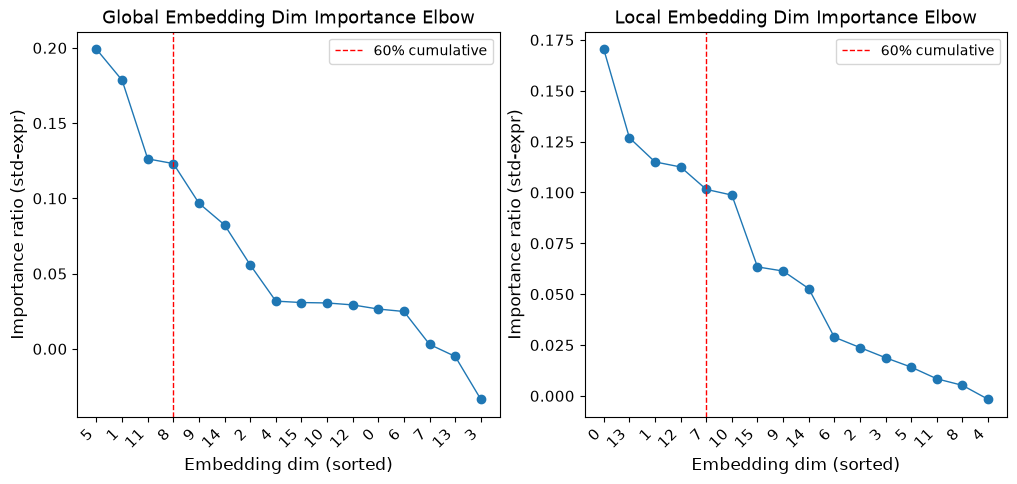

In [23]:
from interscale.pl import dim_importance_elbow
result_global = calculate_dim_importance(
    adata,
    s_key="_global_std_gene_loadings",
    z_key="_global_emb",
    mode="full",
    use_ratio=True,
    cumulative_cutoff=0.60,
    spacing=2,
)
result_local = calculate_dim_importance(
    adata,
    s_key="_local_std_gene_loadings",
    z_key="_local_emb",
    mode="full",
    use_ratio=True,
    cumulative_cutoff=0.60,
    spacing=2,
)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
interscale.pl.dim_importance_elbow(result_local, title="Local Embedding Dim Importance Elbow", ax=axes[1])
interscale.pl.dim_importance_elbow(result_global, title="Global Embedding Dim Importance Elbow", ax=axes[0])

In [24]:
global_dim = [5, 1, 11, 8]
local_dim = [0, 13, 1, 12, 7]

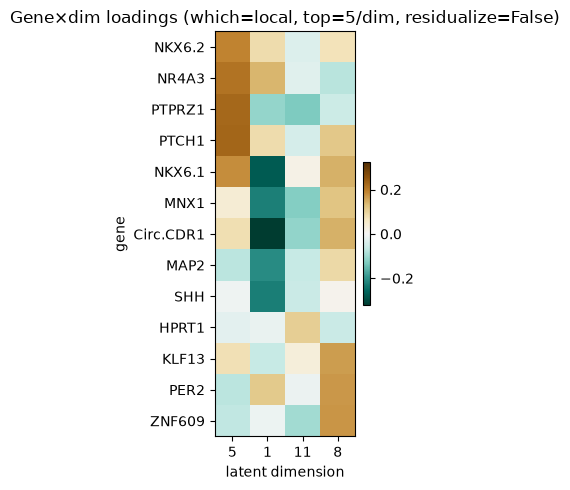

In [28]:
df_global, ax = get_genes_dim(
    adata,
    which="local",
    dims=global_dim,
    n_top=5,
    X_layer="log1p_norm",
    min_frac=0.1,
    rank_by="loading_x_sd",
    enforce_specificity=True,
    specificity_min=1.5,
    # residualize=True,
    plot=True,
    figsize=(3.3, 5),
)

In [31]:
adata.X = adata.layers['log1p_norm']

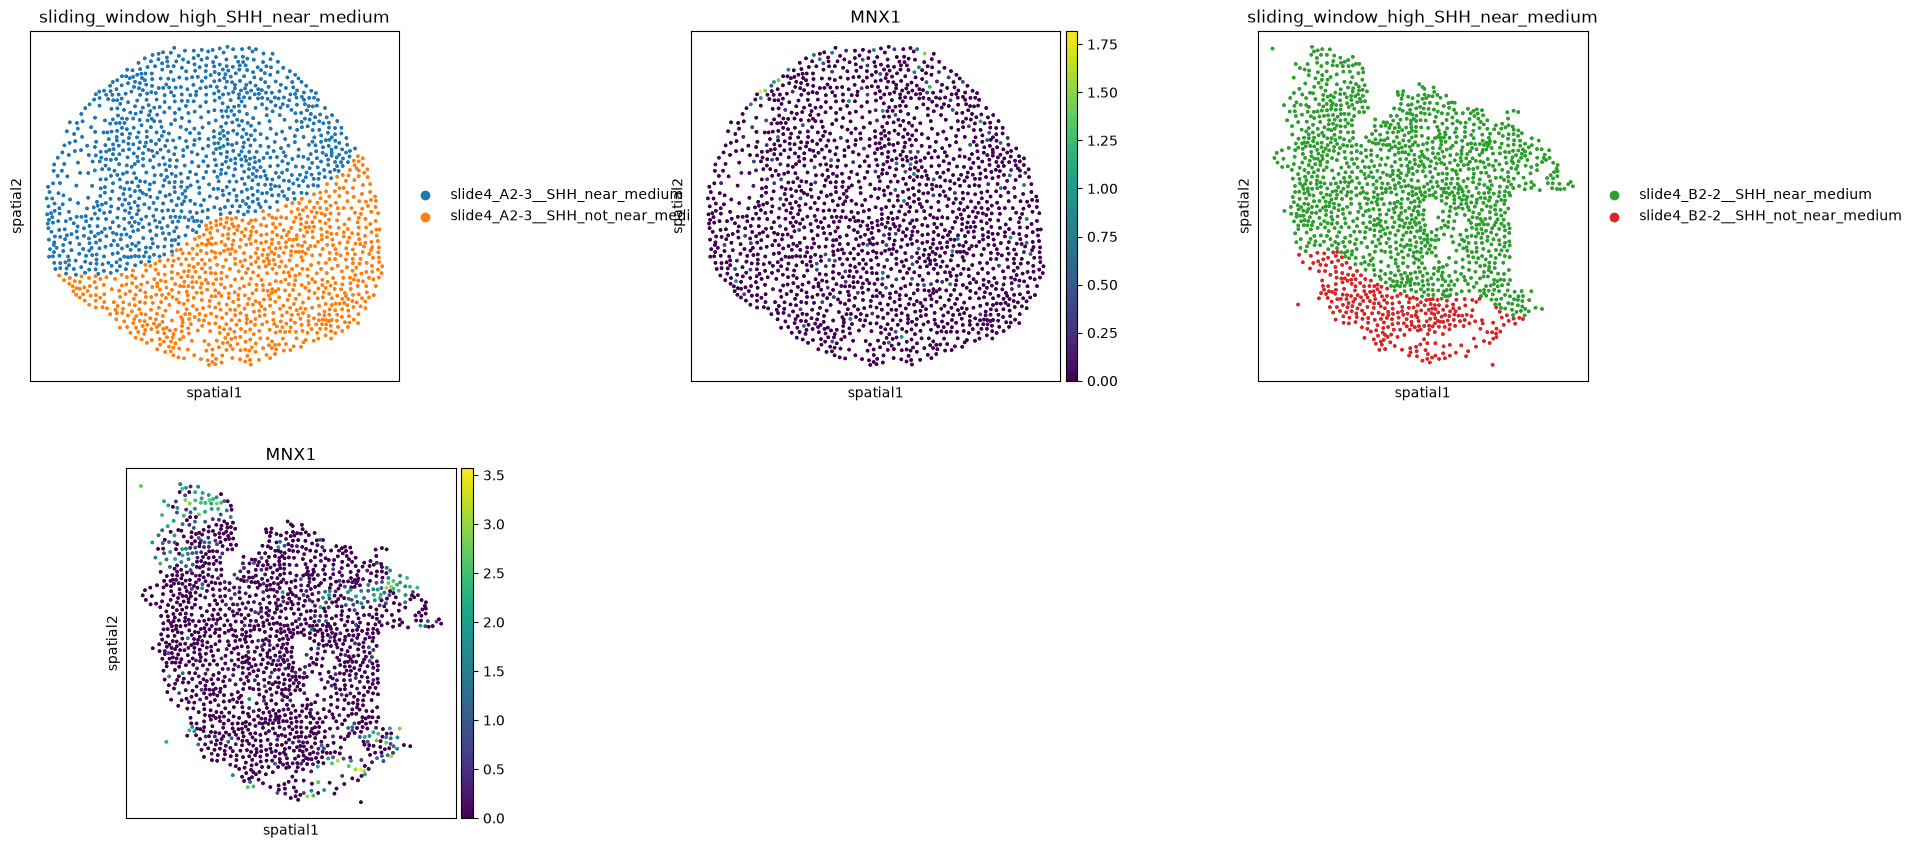

In [34]:
sq.pl.spatial_scatter(
    adata[adata.obs['sample'].isin([slides["Ctrl"], slides["SSH"]])],
    spatial_key = 'spatial',
    library_key='sample', 
    #library_id = [839, 6],
    color=["sliding_window_high_SHH_near_medium", 'MNX1'], #cell_type_coarse",
    shape= None,
    ncols = 3,
    size = 10,
)